## Importing libraries

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

### Loading the dataset

FER2013 dataset was chosen because it is a standard benchmark dataset for facial emotion recognition tasks. It contains grayscale images of faces labeled with seven different emotions. Although the images are low resolution which is 48×48 the dataset is widely used in research making it suitable for testing and evaluating deep learning models. It also provides a realistic challenge due to noise and similarity between emotions.

In [3]:
df = pd.read_csv("C:/Users/vishu/OneDrive/Desktop/fer2013/fer2013.csv") 

print(df.head())
print(df['emotion'].value_counts())

   emotion                                             pixels     Usage
0        0  70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...  Training
1        0  151 150 147 155 148 133 111 140 170 174 182 15...  Training
2        2  231 212 156 164 174 138 161 173 182 200 106 38...  Training
3        4  24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...  Training
4        6  4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...  Training
emotion
3    8989
6    6198
4    6077
2    5121
0    4953
5    4002
1     547
Name: count, dtype: int64


### Converting pixels into images

In [4]:
def process_pixels(pixels):
    pixels = np.fromstring(pixels, sep=' ', dtype=np.float32)
    return pixels.reshape(48, 48)

df['pixels'] = df['pixels'].apply(process_pixels)

X = np.stack(df['pixels'].values)
y = df['emotion'].values

# ✅ Normalize ONCE (correct way)
X = X / 255.0

# Add channel dimension for CNN
X = X.reshape(-1, 1, 48, 48)

print("Check:", X[0].min(), X[0].max(), X[0].shape)

Check: 0.043137256 0.8235294 (1, 48, 48)


### Preparing the data

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
class EmotionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [7]:
train_dataset = EmotionDataset(X_train, y_train)
test_dataset = EmotionDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

## CNN model

CNN is a deep learning model that helps computers understand images by learning patterns like eyes, mouth, and facial expressions.

In [8]:
class BetterCNN(nn.Module):
    def __init__(self):
        super(BetterCNN, self).__init__()
        
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2)
        )
        
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 6 * 6, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 7)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

model = BetterCNN()

### Training setup

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

epochs = 20

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 704.2578
Epoch 2, Loss: 592.0374
Epoch 3, Loss: 535.7008
Epoch 4, Loss: 484.9119
Epoch 5, Loss: 433.8058
Epoch 6, Loss: 381.0693
Epoch 7, Loss: 331.5036
Epoch 8, Loss: 281.6874
Epoch 9, Loss: 237.8689
Epoch 10, Loss: 204.3754
Epoch 11, Loss: 174.9771
Epoch 12, Loss: 156.3449
Epoch 13, Loss: 141.2453
Epoch 14, Loss: 130.6835
Epoch 15, Loss: 116.9330
Epoch 16, Loss: 112.7402
Epoch 17, Loss: 104.1406
Epoch 18, Loss: 98.1613
Epoch 19, Loss: 92.7088
Epoch 20, Loss: 88.8514


### Evaluate model

In [10]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 58.34%


Our model achieved a test accuracy of 58.34% indicating that it can correctly classify facial emotions in more than half of the cases. Considering our FER2013 a low resolution and noisy dataset with subtle differences between emotional expressions so our level of accuracy demonstrates that the CNN model is able to learn meaningful facial features. The performance is especially strong for distinct emotions such as happiness and surprise, while lower accuracy is observed for similar emotions like sadness, fear, and neutrality

In [11]:
emotion_labels = {
    0: "Angry",
    1: "Disgust",
    2: "Fear",
    3: "Happy",
    4: "Sad",
    5: "Surprise",
    6: "Neutral"
}

## Seeing the predictions

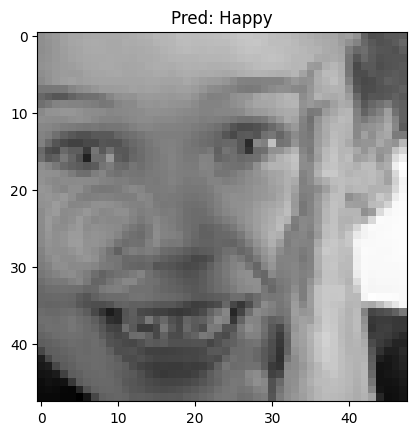

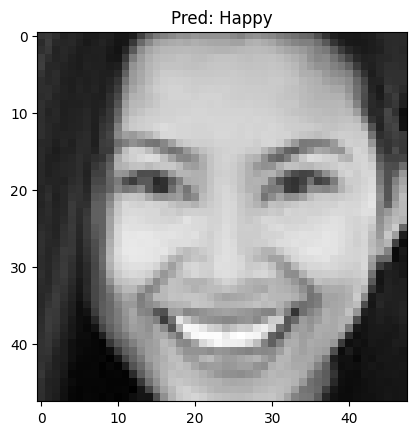

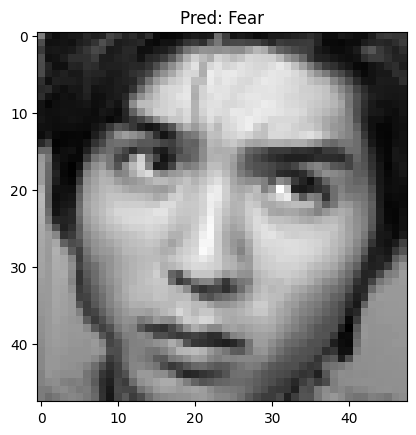

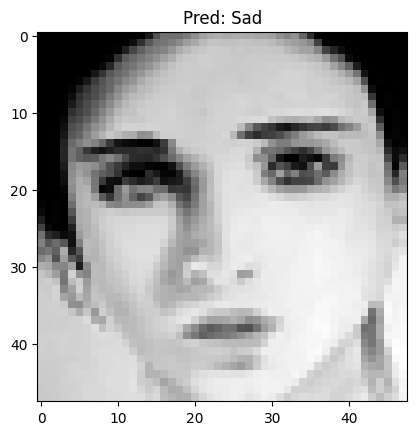

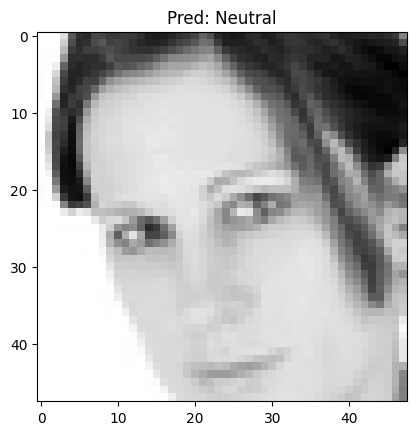

In [12]:
import matplotlib.pyplot as plt

images, labels = next(iter(test_loader))
outputs = model(images)
_, preds = torch.max(outputs, 1)

for i in range(5):
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"Pred: {emotion_labels[preds[i].item()]}")
    plt.show()

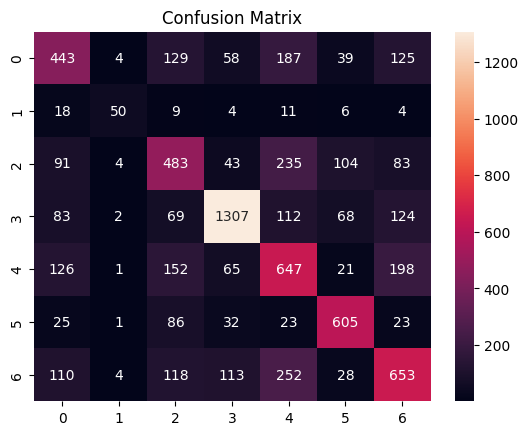

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

Confusion matrix shows that the model performs well on distinct emotions such as Happy, Surprise and Neutral. But it struggles to differentiate between similar emotions like Sad, Fear, and Angry which often share similar facial features. This is a known challenge in emotion recognition tasks, especially when it is low resolution datasets like FER2013.